In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("cleaned_superstore.csv")

In [ ]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,...,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [5]:
#data type
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

In [15]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [14]:
#Fix Data Inconsistencies
df.Category.unique()


array(['Office Supplies', 'Technology', 'Furniture'], dtype=object)

In [10]:
df["Sub.Category"].unique()

array(['Paper', 'Art', 'Storage', 'Appliances', 'Supplies', 'Envelopes',
       'Fasteners', 'Labels', 'Binders', 'Accessories', 'Phones',
       'Copiers', 'Machines', 'Tables', 'Bookcases', 'Chairs',
       'Furnishings'], dtype=object)

In [16]:
cat_cols = ["Category", "Sub.Category", "Ship.Mode", "Market", "Region", "Segment"]

for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Category:
['Office Supplies' 'Technology' 'Furniture']

Unique values in Sub.Category:
['Paper' 'Art' 'Storage' 'Appliances' 'Supplies' 'Envelopes' 'Fasteners'
 'Labels' 'Binders' 'Accessories' 'Phones' 'Copiers' 'Machines' 'Tables'
 'Bookcases' 'Chairs' 'Furnishings']

Unique values in Ship.Mode:
['Second Class' 'Standard Class' 'Same Day' 'First Class']

Unique values in Market:
['US' 'EU' 'LATAM' 'Africa' 'APAC' 'EMEA' 'Canada']

Unique values in Region:
['West' 'East' 'South' 'Central' 'Africa' 'Central Asia' 'North Asia'
 'Caribbean' 'North' 'EMEA' 'Oceania' 'Southeast Asia' 'Canada']

Unique values in Segment:
['Consumer' 'Home Office' 'Corporate']


In [17]:
print(df[df["Sales"] < 0])
print(df[df["Quantity"] < 0])
print(df[df["Shipping.Cost"] < 0])

Empty DataFrame
Columns: [Category, City, Country, Customer.ID, Customer.Name, Discount, Market, 记录数, Order.Date, Order.ID, Order.Priority, Product.ID, Product.Name, Profit, Quantity, Region, Row.ID, Sales, Segment, Ship.Date, Ship.Mode, Shipping.Cost, State, Sub.Category, Year, Market2, weeknum]
Index: []

[0 rows x 27 columns]
Empty DataFrame
Columns: [Category, City, Country, Customer.ID, Customer.Name, Discount, Market, 记录数, Order.Date, Order.ID, Order.Priority, Product.ID, Product.Name, Profit, Quantity, Region, Row.ID, Sales, Segment, Ship.Date, Ship.Mode, Shipping.Cost, State, Sub.Category, Year, Market2, weeknum]
Index: []

[0 rows x 27 columns]
Empty DataFrame
Columns: [Category, City, Country, Customer.ID, Customer.Name, Discount, Market, 记录数, Order.Date, Order.ID, Order.Priority, Product.ID, Product.Name, Profit, Quantity, Region, Row.ID, Sales, Segment, Ship.Date, Ship.Mode, Shipping.Cost, State, Sub.Category, Year, Market2, weeknum]
Index: []

[0 rows x 27 columns]


In [18]:
#Handling Outliers
df[["Sales", "Quantity", "Profit", "Shipping.Cost"]].describe()


,Sales,Quantity,Profit,Shipping.Cost
count,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,28.610982,26.375818
std,487.567175,2.278766,174.340972,57.296810
min,0.000000,1.000000,-6599.978000,0.002000
25%,31.000000,2.000000,0.000000,2.610000
50%,85.000000,3.000000,9.240000,7.790000
75%,251.000000,5.000000,36.810000,24.450000
max,22638.000000,14.000000,8399.976000,933.570000


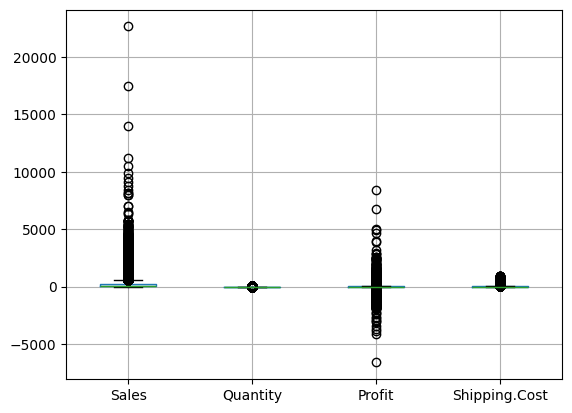

In [19]:
import matplotlib.pyplot as plt

df[["Sales", "Quantity", "Profit", "Shipping.Cost"]].boxplot()
plt.show()

In [6]:
#Create New Columns
df["Month"] = df["Order.Date"].dt.month
df["Day"] = df["Order.Date"].dt.day
df["Day_Name"] = df["Order.Date"].dt.day_name()

In [8]:
df.head(3)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Month,Day,Day_Name
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,Second Class,4.37,California,Paper,2011,North America,2,1,7,Friday
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,Standard Class,0.94,California,Paper,2011,North America,4,1,21,Friday
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,Standard Class,1.81,California,Paper,2011,North America,32,8,5,Friday


In [9]:
df[["Order.Date", "Month", "Day", "Day_Name"]].head()

,Order.Date,Month,Day,Day_Name
0,2011-01-07,1,7,Friday
1,2011-01-21,1,21,Friday
2,2011-08-05,8,5,Friday
3,2011-08-05,8,5,Friday
4,2011-09-29,9,29,Thursday


In [10]:
df.to_csv("final_cleaned_superstore.csv", index=False)